In [1]:
import pandas as pd
import numpy as np
import openpyxl

In [2]:
!pip install openpyxl

# Cargo

In [4]:
cargo = pd.read_excel(
    "/content/srcsc-2026-claims-cargo.xlsx",
    engine="openpyxl", sheet_name ="freq"
)

In [5]:
cargo = cargo.drop(columns=["CARGO_TYPE (CLEAN)"])

## Bersihin data

In [6]:
cargo["cargo_type_clean"] = (
    cargo["cargo_type"]
    .astype(str)
    .str.replace(r"_\?\?\?\d+", "", regex=True)
)

cargo.loc[cargo["cargo_type"].isna(), "cargo_type_clean"] = np.nan

cargo["container_type_clean"] = (
    cargo["container_type"]
    .astype(str)
    .str.replace(r"_\?\?\?\d+", "", regex=True)
)

cargo.loc[cargo["container_type"].isna(), "container_type_clean"] = np.nan

In [7]:
cargo["policy_id_clean"] = (
    cargo["policy_id"]
    .str.replace(r"[?_].*$", "", regex=True)
)

cargo["shipment_id_clean"] = (
    cargo["shipment_id"]
    .str.replace(r"[?_].*$", "", regex=True)
)

In [8]:
cargo1 = cargo.copy()
cargo1 = cargo1.drop(columns=["policy_id","container_type","cargo_type","shipment_id"])



## Missing Value

In [9]:
import numpy as np

df = cargo1.copy()

num_cols = df.select_dtypes(include="number").columns

df[num_cols] = df[num_cols].mask(df[num_cols] < 0, np.nan)

In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct (%)": df.isna().mean() * 100
}).round(2).sort_values("missing_pct (%)", ascending=False)

missing_summary


,missing_count,missing_pct (%)
cargo_value,446,0.36
pilot_experience,409,0.33
route_risk,398,0.32
vessel_age,397,0.32
distance,405,0.32
solar_radiation,400,0.32
weight,382,0.31
exposure,388,0.31
debris_density,384,0.31
transit_duration,337,0.27


# Severity

In [11]:
cargo_sev = pd.read_excel(
    "/content/srcsc-2026-claims-cargo.xlsx",
    engine="openpyxl", sheet_name ="sev"
)

In [12]:
cargo_sev["cargo_type_clean"] = (
    cargo_sev["cargo_type"]
    .astype(str)
    .str.replace(r"_\?\?\?\d+", "", regex=True)
)

cargo_sev.loc[cargo_sev["cargo_type"].isna(), "cargo_type_clean"] = np.nan


cargo_sev["container_type_clean"] = (
    cargo_sev["container_type"]
    .astype(str)
    .str.replace(r"_\?\?\?\d+", "", regex=True)
)

cargo_sev.loc[cargo_sev["container_type"].isna(), "container_type_clean"] = np.nan

In [13]:
cargo_sev["policy_id_clean"] = (
    cargo_sev["policy_id"]
    .str.replace(r"[?_].*$", "", regex=True)
)

cargo_sev["shipment_id_clean"] = (
    cargo_sev["shipment_id"]
    .str.replace(r"[?_].*$", "", regex=True)
)

In [14]:
cargo2 = cargo_sev.copy()
cargo2 = cargo2.drop(columns=["policy_id","container_type","cargo_type","shipment_id"])

In [15]:
import numpy as np

df_sev = cargo2.copy()

num_cols = df_sev.select_dtypes(include="number").columns

df_sev[num_cols] = df_sev[num_cols].mask(df_sev[num_cols] < 0, np.nan)

In [16]:
missing_summary = pd.DataFrame({
    "missing_count": df_sev.isna().sum(),
    "missing_pct (%)": df_sev.isna().mean() * 100
}).round(2).sort_values("missing_pct (%)", ascending=False)

missing_summary


,missing_count,missing_pct (%)
debris_density,113,0.37
transit_duration,111,0.36
cargo_value,99,0.32
claim_seq,97,0.32
solar_radiation,95,0.31
route_risk,95,0.31
exposure,95,0.31
weight,91,0.30
vessel_age,90,0.29
claim_amount,89,0.29


#MATCHING

In [17]:
#CEK APAKAH SEMUA SEV ADA DI FEQ
# Set referensi
cargo_policy_set = set(df["policy_id_clean"].dropna().unique())
cargo_shipment_set = set(df["shipment_id_clean"].dropna().unique())

# Flag validasi (policy OR shipment)
df_sev["policy_or_shipment_match"] = (
    df_sev["policy_id_clean"].isin(cargo_policy_set)
    | df_sev["shipment_id_clean"].isin(cargo_shipment_set)
)
df_sev["policy_or_shipment_match"].value_counts()

,count
policy_or_shipment_match,
True,30650


In [18]:
import pandas as pd
import numpy as np

df_freq = df.copy()
# Daftar kolom atribut untuk fallback match
attr_cols = [
    "cargo_value", "weight", "route_risk", "distance",
    "transit_duration", "vessel_age",
    "container_type_clean"
]

# Inisialisasi kolom baru
df_freq["claim_count_same"] = np.nan

# --- 1️⃣ Strong match: policy_id_clean & shipment_id_clean ada ---
strong_mask = df_freq["policy_id_clean"].notna() & df_freq["shipment_id_clean"].notna()

# Buat dict untuk counting occurrence di df_sev
sev_counts = df_sev.groupby(["policy_id_clean", "shipment_id_clean"]).size().to_dict()

# Ambil hanya baris strong_mask
for idx in df_freq[strong_mask].index:
    key = (df_freq.at[idx, "policy_id_clean"], df_freq.at[idx, "shipment_id_clean"])
    df_freq.at[idx, "claim_count_same"] = sev_counts.get(key, 0)  # kalau ga ada di sev → 0

# --- 2️⃣ Fallback match: salah satu ID kosong, tapi tidak keduanya ---
fallback_mask = ~strong_mask & (
    df_freq["policy_id_clean"].notna() | df_freq["shipment_id_clean"].notna()
)

for idx in df_freq[fallback_mask].index:
    # Ambil nilai baris df_freq
    policy_val = df_freq.at[idx, "policy_id_clean"]
    shipment_val = df_freq.at[idx, "shipment_id_clean"]

    # Filter df_sev sesuai yang ada
    if pd.notna(policy_val):
        subset = df_sev[df_sev["policy_id_clean"] == policy_val].copy()
    elif pd.notna(shipment_val):
        subset = df_sev[df_sev["shipment_id_clean"] == shipment_val].copy()
    else:
        continue  # keduanya NaN → nanti tetap NaN

    # Hitung jumlah kolom attribute match per baris
    n_matches = ((subset[attr_cols] == df_freq.loc[idx, attr_cols]).sum(axis=1))

    # Ambil baris yang match ≥5
    count = (n_matches >= 5).sum()

    # Masukkan ke df_freq
    df_freq.at[idx, "claim_count_same"] = count

# --- 3️⃣ Kedua ID NaN → biarkan NaN (tidak diubah) ---

# Optional: ubah tipe integer tapi tetap biarkan NaN
df_freq["claim_count_same"] = df_freq["claim_count_same"].astype("Int64")

In [19]:
# Menampilkan baris di mana claim_count tidak sama dengan claim_count_same
df_berbeda = df_freq[df_freq['claim_count'] != df_freq['claim_count_same']]

# Menampilkan hasilnya
df_berbeda

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,claim_count,cargo_type_clean,container_type_clean,policy_id_clean,shipment_id_clean,claim_count_same
451,6240000.0,120000.0,4.0,26.67,15.478,5.360,4.111,0.363,0.321,0.809,1.0,cobalt,QuantumCrate Module,CL-063445,S-178295,0
1076,130800000.0,2400.0,3.0,17.18,10.586,22.672,3.428,0.393,0.165,0.115,1.0,platinum,LongHaul Vault Canister,CL-947390,S-884589,0
1664,4250000.0,50000.0,3.0,21.01,10.793,13.725,36.166,0.142,0.260,0.112,3.0,rare earths,QuantumCrate Module,CL-401753,S-305011,2
2079,98100000.0,1800.0,2.0,47.96,25.959,20.624,19.811,0.310,0.261,0.229,2.0,platinum,QuantumCrate Module,CL-536243,S-661124,1
2176,1400000.0,200000.0,3.0,1.58,1.000,14.404,24.165,0.061,0.111,0.134,2.0,titanium,DockArc Freight Case,CL-743137,S-316168,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120587,1000000.0,100000.0,3.0,9.63,4.345,23.986,29.837,0.322,0.306,0.199,1.0,supplies,HardSeal Transit Crate,CL-556442,S-965870,0
121614,678000000.0,5000.0,3.0,19.93,12.563,13.257,19.060,0.077,0.311,0.219,1.0,gold,DeepSpace Haulbox,CL-043803,S-035697,0
122389,3825000.0,45000.0,2.0,6.07,4.099,12.429,31.704,0.085,0.009,0.184,1.0,rare earths,DockArc Freight Case,CL-498541,S-486046,0
122699,1575000.0,225000.0,3.0,3.56,2.082,17.923,10.044,0.242,0.000,0.440,1.0,titanium,DeepSpace Haulbox,CL-428060,S-313008,0


In [20]:
import pandas as pd
import numpy as np

df_berbeda = df_freq[df_freq['claim_count'] != df_freq['claim_count_same']].copy()

attr_check = ["distance", "weight", "transit_duration", "cargo_value", "vessel_age"]
min_attr_match = 3  # minimal kolom yang harus sama untuk dihitung

for idx in df_berbeda.index:
    policy_val = df_berbeda.at[idx, "policy_id_clean"]
    shipment_val = df_berbeda.at[idx, "shipment_id_clean"]

    total_count = 0  # initialize total claim count

    # --- Strong match: policy + shipment ada ---
    if pd.notna(policy_val) and pd.notna(shipment_val):
        strong_match = df_sev[
            (df_sev["policy_id_clean"] == policy_val) &
            (df_sev["shipment_id_clean"] == shipment_val)
        ]
        total_count += strong_match.shape[0]

    # --- Fallback policy_id match ---
    if pd.notna(policy_val):
        fallback_policy = df_sev[
            (df_sev["policy_id_clean"] == policy_val) &
            ((df_sev["shipment_id_clean"] != shipment_val) | df_sev["shipment_id_clean"].isna())
        ]
        # cek kolom attribute: hitung baris yang minimal 2 kolom sama
        n_matches = (fallback_policy[attr_check] == df_berbeda.loc[idx, attr_check]).sum(axis=1)
        fallback_count = (n_matches >= min_attr_match).sum()
        total_count += fallback_count

    # --- Fallback shipment_id match ---
    if pd.notna(shipment_val):
        fallback_shipment = df_sev[
            (df_sev["shipment_id_clean"] == shipment_val) &
            ((df_sev["policy_id_clean"] != policy_val) | df_sev["policy_id_clean"].isna())
        ]
        n_matches2 = (fallback_shipment[attr_check] == df_berbeda.loc[idx, attr_check]).sum(axis=1)
        fallback_count2 = (n_matches2 >= min_attr_match).sum()
        total_count += fallback_count2

    # --- Keduanya NaN → tetap NaN ---
    if pd.isna(policy_val) and pd.isna(shipment_val):
        df_berbeda.at[idx, "claim_count_same"] = np.nan
    else:
        df_berbeda.at[idx, "claim_count_same"] = total_count

# Optional: ubah tipe integer tapi tetap biarkan NaN
df_berbeda["claim_count_same"] = df_berbeda["claim_count_same"].astype("Int64")

# Update df_freq
df_freq.loc[df_berbeda.index, "claim_count_same"] = df_berbeda["claim_count_same"]

In [21]:
# Menampilkan baris di mana claim_count tidak sama dengan claim_count_same
df_berbeda2 = df_freq[df_freq['claim_count'] != df_freq['claim_count_same']]

# Menampilkan hasilnya
df_berbeda2

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,claim_count,cargo_type_clean,container_type_clean,policy_id_clean,shipment_id_clean,claim_count_same
7838,800000.0,80000.0,5.0,1.58,1.077,17.243,18.316,0.071,0.251,0.938,9.970089,supplies,QuantumCrate Module,CL-685537,S-867433,1
23438,3825000.0,45000.0,3.0,40.27,29.264,8.581,13.721,0.308,0.107,0.560,10.717906,rare earths,LongHaul Vault Canister,CL-846098,S-062656,1
23711,12300000.0,150000.0,1.0,26.11,13.893,11.494,36.595,0.119,0.309,0.179,22.296826,lithium,QuantumCrate Module,CL-988767,S-512062,3
23781,6240000.0,120000.0,3.0,1.58,1.000,15.496,27.702,0.304,0.117,0.102,9.406096,cobalt,DeepSpace Haulbox,CL-760042,S-394954,1
31168,1750000.0,250000.0,3.0,24.70,15.353,8.747,8.136,0.107,0.231,0.189,20.097888,titanium,QuantumCrate Module,CL-758745,S-545814,2
47493,339000000.0,2500.0,3.0,42.39,26.296,14.957,3.262,0.287,0.066,0.146,24.540541,gold,DeepSpace Haulbox,CL-743554,S-864673,2
49768,2975000.0,35000.0,4.0,16.74,10.559,7.943,40.241,0.212,0.257,0.203,29.389022,rare earths,DeepSpace Haulbox,CL-126504,S-919098,2
51117,900000.0,90000.0,3.0,26.53,24.711,24.242,30.739,0.260,0.212,0.691,12.372843,supplies,DockArc Freight Case,CL-069674,S-765182,1
52587,474600000.0,3500.0,3.0,64.88,36.060,16.374,12.740,0.326,0.317,0.244,23.420846,gold,LongHaul Vault Canister,CL-062205,S-924048,2
56267,2975000.0,35000.0,3.0,1.58,1.121,7.735,24.845,0.155,0.477,0.380,7.427051,rare earths,LongHaul Vault Canister,CL-061922,S-010334,1


In [22]:
import pandas as pd

# Misal df_freq sudah ada dan sudah terupdate
df_freq.to_excel("df_freq_updated.xlsx", index=False)

In [23]:
import pandas as pd

# Misal df_freq sudah ada dan sudah terupdate
df_sev.to_excel("df_sev_updated.xlsx", index=False)

#JANGAN LIAT DLU

In [ ]:
# 1️⃣ Pilih baris yang perlu dicek
mismatch_mask = df_freq["claim_count"] != df_freq["claim_count_same"]

# Ambil subset df_freq yang mismatch
df_check = df_freq[mismatch_mask].copy()

# 2️⃣ Ambil baris df_sev relevan untuk policy_id / shipment_id
# Buat mask di df_sev
sev_relevant = df_sev[
    df_sev["policy_id_clean"].isin(df_check["policy_id_clean"].dropna()) |
    df_sev["shipment_id_clean"].isin(df_check["shipment_id_clean"].dropna())
].copy()

# 3️⃣ Merge untuk membandingkan distance & transit_duration
# Merge left df_check ke sev_relevant untuk matching policy_id atau shipment_id
merged = df_check.merge(
    sev_relevant,
    how="left",
    left_on=["policy_id_clean", "shipment_id_clean"],
    right_on=["policy_id_clean", "shipment_id_clean"],
    suffixes=("_freq", "_sev")
)

# 4️⃣ Cek distance & transit_duration sama
merged["distance_match"] = merged["distance_freq"] == merged["distance_sev"]
merged["duration_match"] = merged["transit_duration_freq"] == merged["transit_duration_sev"]

merged["both_match"] = merged["distance_match"] & merged["duration_match"]

# 5️⃣ Hitung claim_count baru untuk baris df_freq
# Groupby index df_freq, count baris matching
claim_count_recalc = merged.groupby(merged.index)["both_match"].sum()

# 6️⃣ Update df_freq claim_count_same untuk baris mismatch
df_freq.loc[claim_count_recalc.index, "claim_count_same"] = claim_count_recalc.astype("Int64")

In [ ]:
mismatch_mask = df_freq["claim_count"] != df_freq["claim_count_same"]
# lalu merge df_check dengan df_sev dan cek distance & transit_duration
# hitung claim_count baru → update df_freq["claim_count_same"]

In [ ]:
# 1️⃣ Lihat beberapa baris pertama
df_freq.head(10)

# 2️⃣ Lihat baris-baris yang di-update (misal claim_count_same berubah dari claim_count)
updated_mask = df_freq["claim_count_same"] != df_freq["claim_count"]
df_freq_updated = df_freq[updated_mask]


In [ ]:
# Menampilkan baris di mana claim_count tidak sama dengan claim_count_same
df_berbeda = df_freq_updated[df_freq_updated['claim_count'] != df_freq_updated['claim_count_same']]

# Menampilkan hasilnya
df_berbeda

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,claim_count,cargo_type_clean,container_type_clean,policy_id_clean,shipment_id_clean,claim_count_same,claim_count_initial
1,8320000.0,160000.0,5.0,33.69,20.794,12.828,6.305,0.255,0.296,0.148,3.0,cobalt,DockArc Freight Case,CL-654613,S-366678,0,0
2,12300000.0,150000.0,1.0,10.93,6.445,6.039,31.811,0.076,0.252,0.289,0.0,lithium,QuantumCrate Module,CL-569825,S-237760,1,1
3,500000.0,50000.0,4.0,13.49,9.583,17.533,9.695,0.150,0.350,0.813,0.0,supplies,DockArc Freight Case,CL-707560,S-045399,1,1
4,2550000.0,30000.0,3.0,1.58,1.000,17.157,19.357,0.149,0.000,0.959,0.0,rare earths,DeepSpace Haulbox,CL-008111,S-280272,1,1
5,600000.0,60000.0,4.0,13.62,5.579,15.865,9.782,0.138,0.358,0.394,0.0,supplies,DockArc Freight Case,CL-287275,S-342642,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120587,1000000.0,100000.0,3.0,9.63,4.345,23.986,29.837,0.322,0.306,0.199,1.0,supplies,HardSeal Transit Crate,CL-556442,S-965870,0,0
121614,678000000.0,5000.0,3.0,19.93,12.563,13.257,19.060,0.077,0.311,0.219,1.0,gold,DeepSpace Haulbox,CL-043803,S-035697,0,0
122389,3825000.0,45000.0,2.0,6.07,4.099,12.429,31.704,0.085,0.009,0.184,1.0,rare earths,DockArc Freight Case,CL-498541,S-486046,0,0
122699,1575000.0,225000.0,3.0,3.56,2.082,17.923,10.044,0.242,0.000,0.440,1.0,titanium,DeepSpace Haulbox,CL-428060,S-313008,0,0


## Melihat Korelasi antar numerik (kecil banget)

In [ ]:
num_cols = [
    "cargo_value", "weight", "distance", "transit_duration",
    "pilot_experience", "vessel_age",
    "solar_radiation", "debris_density", "exposure"
]

cargo[num_cols + ["claim_count"]].corr()["claim_count"].sort_values(ascending=False)

,claim_count
claim_count,1.000000
debris_density,0.007750
solar_radiation,0.002893
weight,0.002562
transit_duration,0.001930
distance,0.000255
vessel_age,-0.001614
cargo_value,-0.003496
pilot_experience,-0.007108
exposure,-0.198606


## Penanganan Missing Value

In [ ]:
# Karena claim count itu target dalam frequensi dan dia NaN maka aku akan drop baris yang Claim count NaN.
# Justfikasi : Ga boleh diprediksi, krna itu kan data leakage. Ga mungkin isi 0 juga krna blm tentu, kalau isi mean dan median juga aneh, krna pada dasarnya gatau ini tuh klaim atau ga
# Lebih baik dihapus dan persentasenya juga masih kecil 0.17
# Numerik = Median biar lebih robust aja, sedangkan Kategorik pake modus (Simple Imputation aja)

In [ ]:
num_cols = [
    "cargo_value", "weight", "distance", "transit_duration",
    "pilot_experience", "vessel_age", "route_risk",
    "solar_radiation", "debris_density", "exposure"
]
cat_cols = [
    "cargo_type_clean",
    "container_type_clean"
]


In [ ]:
df1 = cargo.copy()

In [ ]:
df1[num_cols] = df1[num_cols].fillna(df1[num_cols].median())

In [ ]:
for col in cat_cols:
    df1[col] = df1[col].fillna(df1[col].mode()[0])

# Liat Min Max Data

In [ ]:
# Pilih kolom numerik saja
numeric_summary = (
    df1
    .select_dtypes(include="number")
    .agg(["min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

numeric_summary

,variable,min,max
0,cargo_value,-6.780000e+08,1.200557e+10
1,weight,-2.500000e+05,4.924279e+06
2,route_risk,-5.000000e+00,9.442383e+01
3,distance,-6.767000e+01,1.290702e+03
4,transit_duration,-5.967200e+01,7.974264e+02
5,pilot_experience,-3.000000e+01,4.223463e+02
6,vessel_age,-5.000000e+01,9.031653e+02
7,solar_radiation,-5.720000e-01,8.021458e+00
8,debris_density,-5.820000e-01,9.601451e+00
9,exposure,-9.270000e-01,1.616814e+01


In [ ]:
import numpy as np

df2 = df1.copy()

num_cols = df2.select_dtypes(include="number").columns

df2[num_cols] = df2[num_cols].mask(df2[num_cols] < 0, np.nan)

In [ ]:
missing_pct = (
    df2
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_pct"})
)

missing_pct

,variable,missing_pct
0,policy_id,0.24
1,shipment_id,0.22
2,cargo_type,0.23
3,cargo_value,0.17
4,weight,0.16
5,route_risk,0.17
6,distance,0.17
7,transit_duration,0.14
8,pilot_experience,0.15
9,vessel_age,0.16


In [ ]:
df2["n_missing"] = df2.isna().sum(axis=1)

df2["n_missing"].value_counts().sort_index()

,count
n_missing,
0,121624
1,3316
2,42


# Average Tiap Container

In [ ]:
container_cargo_profile = (
    cargo
    .groupby(["container_type_clean", "cargo_type_clean"])
    .agg(
        median_weight=("weight", "median"),
        avg_weight=("weight", "mean"),

        median_distance=("distance", "median"),
        avg_distance=("distance", "mean"),

        avg_route_risk=("route_risk", "mean"),

        median_transit_duration=("transit_duration", "median"),
        avg_transit_duration=("transit_duration", "mean"),

        avg_vessel_age=("vessel_age", "mean"),

        n_obs=("weight", "count")
    )
    .reset_index()
    .sort_values(["median_weight", "avg_distance"], ascending=False)
)

container_cargo_profile.round(2)

,container_type_clean,cargo_type_clean,median_weight,avg_weight,median_distance,avg_distance,avg_route_risk,median_transit_duration,avg_transit_duration,avg_vessel_age,n_obs
34,QuantumCrate Module,titanium,200000.0,189938.26,25.15,27.25,3.02,14.97,16.08,20.20,3592
13,DockArc Freight Case,titanium,200000.0,190768.39,25.28,26.96,2.97,14.72,16.46,20.51,3620
27,LongHaul Vault Canister,titanium,200000.0,190291.61,24.96,25.94,3.06,14.60,15.55,20.34,3497
6,DeepSpace Haulbox,titanium,175000.0,187974.89,25.08,27.14,3.03,14.84,15.91,20.24,3595
20,HardSeal Transit Crate,titanium,175000.0,188358.77,25.38,26.28,3.08,14.80,15.93,20.18,3530
0,DeepSpace Haulbox,cobalt,160000.0,151061.22,24.94,26.77,3.05,14.56,16.10,20.12,3477
14,HardSeal Transit Crate,cobalt,160000.0,155490.69,25.34,26.57,2.99,14.66,15.78,20.25,3622
7,DockArc Freight Case,cobalt,140000.0,151925.81,25.42,27.10,3.04,14.78,16.24,20.70,3524
21,LongHaul Vault Canister,cobalt,140000.0,151302.91,24.83,26.77,3.05,14.50,15.74,20.12,3573
28,QuantumCrate Module,cobalt,140000.0,148849.47,24.94,26.55,3.07,14.59,15.85,20.63,3571


In [ ]:
# Based On Conntainer_Type
container_profile = (
    cargo
    .groupby("container_type_clean")
    .agg(
        median_weight=("weight", "median"),
        avg_weight=("weight", "mean"),

        median_distance=("distance", "median"),
        avg_distance=("distance", "mean"),

        median_pilot_experience=("pilot_experience", "median"),
        avg_pilot_experience=("pilot_experience", "mean"),


        median_route_risk=("route_risk", "median"),
        avg_route_risk=("route_risk", "mean"),

        median_solar_radiation=("solar_radiation", "median"),
        avg_solar_radiation=("solar_radiation", "mean"),

        median_transit_duration=("transit_duration", "median"),
        avg_transit_duration=("transit_duration", "mean"),

        median_vessel_age=("vessel_age", "median"),
        avg_vessel_age=("vessel_age", "mean"),

        n_obs=("weight", "count")
    )
    .reset_index()
    .sort_values(["median_weight", "avg_distance"], ascending=False)
)

container_profile.round(2)

,container_type_clean,median_weight,avg_weight,median_distance,avg_distance,median_pilot_experience,avg_pilot_experience,median_route_risk,avg_route_risk,median_solar_radiation,avg_solar_radiation,median_transit_duration,avg_transit_duration,avg_vessel_age,n_obs
4,QuantumCrate Module,75000.0,82107.34,25.03,26.86,15.02,15.21,3.0,3.01,0.24,0.24,14.68,16.07,20.41,24833
2,HardSeal Transit Crate,75000.0,83275.76,24.90,26.42,14.97,15.22,3.0,3.05,0.24,0.24,14.48,15.89,20.42,24963
1,DockArc Freight Case,70000.0,82524.34,25.09,26.71,15.02,15.24,3.0,3.02,0.24,0.24,14.62,16.03,20.40,24879
3,LongHaul Vault Canister,70000.0,82069.86,25.00,26.63,15.06,15.26,3.0,3.05,0.24,0.24,14.59,15.95,20.32,24799
0,DeepSpace Haulbox,70000.0,81655.06,25.05,26.61,14.97,15.14,3.0,3.05,0.24,0.24,14.69,15.87,20.28,25045


In [ ]:
#Based on Cargo Profile
cargo_profile = (
    cargo
    .groupby("cargo_type_clean")
    .agg(
        median_weight=("weight", "median"),
        avg_weight=("weight", "mean"),

        median_distance=("distance", "median"),
        avg_distance=("distance", "mean"),

        median_route_risk=("route_risk", "median"),
        avg_route_risk=("route_risk", "mean"),

        median_pilot_experience=("pilot_experience", "median"),
        avg_pilot_experience=("pilot_experience", "mean"),

        median_solar_radiation=("solar_radiation", "median"),
        avg_solar_radiation=("solar_radiation", "mean"),

        median_transit_duration=("transit_duration", "median"),
        avg_transit_duration=("transit_duration", "mean"),

        median_avg_vessel_age=("vessel_age", "median"),
        avg_vessel_age=("vessel_age", "mean"),

        n_obs=("weight", "count")
    )
    .reset_index()
    .sort_values(["median_weight", "avg_distance"], ascending=False)
)

cargo_profile.round(2)

,cargo_type_clean,median_weight,avg_weight,median_distance,avg_distance,median_route_risk,avg_route_risk,median_pilot_experience,avg_pilot_experience,median_solar_radiation,avg_solar_radiation,median_transit_duration,avg_transit_duration,avg_vessel_age,n_obs
6,titanium,200000.0,189458.81,25.20,26.72,3.0,3.03,15.00,15.17,0.24,0.24,14.83,15.99,20.30,17876
0,cobalt,140000.0,151726.41,25.02,26.74,3.0,3.04,15.09,15.30,0.24,0.24,14.64,15.94,20.36,17806
2,lithium,105000.0,113870.55,24.96,26.57,3.0,3.02,14.91,15.23,0.24,0.24,14.57,16.01,20.38,17659
5,supplies,80000.0,76265.73,25.21,26.69,3.0,3.06,15.01,15.15,0.24,0.24,14.61,15.93,20.21,17854
4,rare earths,40000.0,38246.28,24.85,26.60,3.0,3.06,15.02,15.19,0.24,0.24,14.61,15.91,20.31,17784
1,gold,3500.0,3797.50,24.98,26.77,3.0,3.01,15.01,15.20,0.24,0.24,14.59,16.11,20.43,17757
3,platinum,2400.0,2278.80,24.78,26.41,3.0,3.04,15.00,15.26,0.24,0.24,14.43,15.81,20.55,17778


## Visualisasi Banyak Klaim Berdasarkan Variabel Kategorik

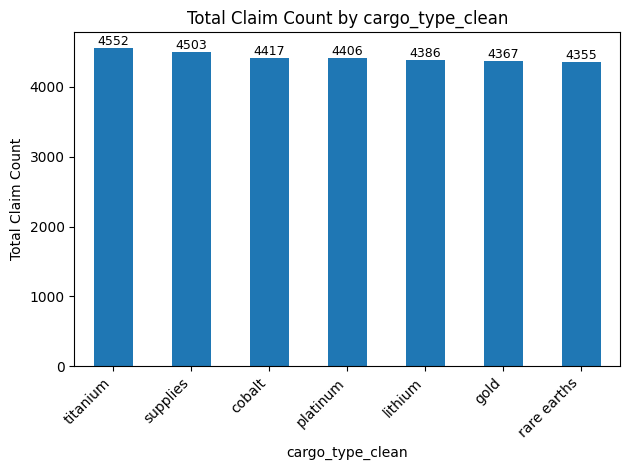

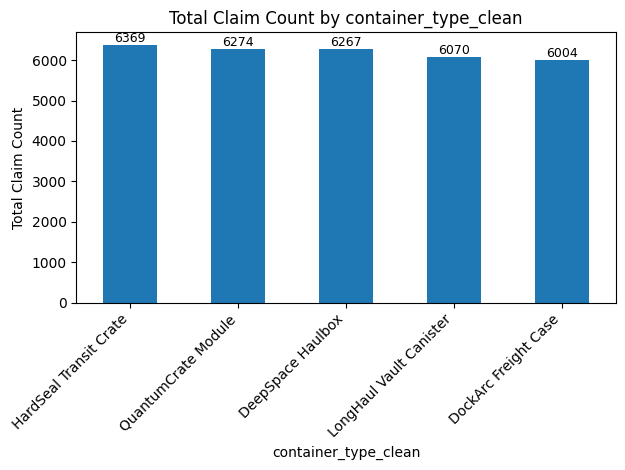

In [ ]:
import matplotlib.pyplot as plt

for col in cat_cols:
    summary = (
        df1
        .groupby(col)["claim_count"]
        .sum()
        .sort_values(ascending=False)
    )

    ax = summary.plot(kind="bar")

    plt.title(f"Total Claim Count by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Claim Count")
    plt.xticks(rotation=45, ha="right")

    # tambah label di atas bar
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.0f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()
